# `pedigraph-sim` demo

This notebook is a walkthrough of `pedigraph-sim` and its core capabilities.

It demonstrates how to:

- define pedigrees
- simulate inheritance with recombination
- inspect descendant homolog mosaics
- reconstruct chromosome-local ancestry as a sequence of local forests
- export those forests to tabular and Newick formats
- convert them to `tskit`

The central ancestry object in this workflow is a **`LocalForestSequence`**:
a sequence of local trees/forests across genomic intervals on a chromosome.

## 1. Imports and notebook display settings

In [1]:
import pedigraph_sim as pg
import pandas as pd
import numpy as np
import toytree

pd.set_option("display.max_colwidth", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.precision", 3)

## 2. A helper for concise forest summaries

Makes it easier to inspect local forests without printing large raw objects.

In [2]:
def summarize_forest(forest):
    return {
        "chromosome": forest.chromosome,
        "interval": (forest.left, forest.right),
        "span": forest.span(),
        "roots": forest.roots(),
        "nodes": forest.nodes(),
        "edges": sorted(forest.edges),
    }

## 3. Build a small three-generation pedigree

We will use a pedigree with four founders, two parents, and one child.
Small enough to inspect by eye but rich enough to produce some interesting ancestry patterns.

In [3]:
model = pg.PedigreeModel(
    pedigree=[
        ("gp1", None, None),
        ("gp2", None, None),
        ("gp3", None, None),
        ("gp4", None, None),
        ("p1", "gp1", "gp2"),
        ("p2", "gp3", "gp4"),
        ("child", "p1", "p2"),
    ],
    chromosomes={
        "chr1": 100.0,
        "chr2": 50.0,
    },
    seed=2,
)

model

<pedigraph_sim.simulate.PedigreeModel>

## 4. Visualize the pedigree

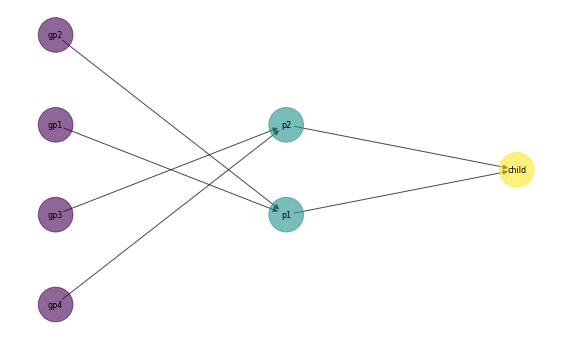

In [4]:
model.draw_pedigree()

## 5. Simulate inheritance through the pedigree

The simulation records ancestry and recombination information through the complete pedigree.

In [5]:
result = model.simulate()
result

SimulationResult(n_individuals=7, generations=0..2, chromosomes=['chr1', 'chr2'], final_generation_ids=['child'])

In [6]:
print(result.summary())

SimulationResult summary
  individuals           : 7
  generations           : 0..2
  chromosomes           : ['chr1', 'chr2']
  final generation ids  : ['child']
  total homologs        : 28
  total segments        : 37


## 6. Inspect the simulated individuals

In [7]:
result.individuals_dataframe()

,individual_id,time,n_chromosomes,n_homologs
0,gp1,0,2,4
1,gp2,0,2,4
2,gp3,0,2,4
3,gp4,0,2,4
4,p1,1,2,4
5,p2,1,2,4
6,child,2,2,4


In [8]:
result.individuals["child"]

SimIndividual(individual_id='child', time=2, homologs_by_chromosome={'chr1': [Homolog(homolog_id=24, chromosome='chr1', individual_id='child', time=2, length=100.0, segments=[Segment(left=0.0, right=6.493056800199325, parent_homolog_id=16, founder_homolog_id=0), Segment(left=6.493056800199325, right=32.16700646941994, parent_homolog_id=16, founder_homolog_id=1), Segment(left=32.16700646941994, right=100.0, parent_homolog_id=16, founder_homolog_id=0)]), Homolog(homolog_id=25, chromosome='chr1', individual_id='child', time=2, length=100.0, segments=[Segment(left=0.0, right=3.719627005774287, parent_homolog_id=20, founder_homolog_id=8), Segment(left=3.719627005774287, right=51.939733629604376, parent_homolog_id=20, founder_homolog_id=9), Segment(left=51.939733629604376, right=100.0, parent_homolog_id=21, founder_homolog_id=12)])], 'chr2': [Homolog(homolog_id=26, chromosome='chr2', individual_id='child', time=2, length=50.0, segments=[Segment(left=0.0, right=50.0, parent_homolog_id=18, fou

## 7. Inspect the child's homologs

Each individual carries two homologs per chromosome.
We start by looking at the child's homologs on `chr1`.

In [9]:
child = result.individuals["child"]
child_chr1 = child.homologs_by_chromosome["chr1"]

for i, h in enumerate(child_chr1):
    print(f"child chr1 homolog {i}")
    print(f"  homolog_id   : {h.homolog_id}")
    print(f"  chromosome   : {h.chromosome}")
    print(f"  individual_id: {h.individual_id}")
    print(f"  time         : {h.time}")
    print(f"  length       : {h.length}")
    print(f"  n_segments   : {len(h.segments)}")
    print()

child chr1 homolog 0
  homolog_id   : 24
  chromosome   : chr1
  individual_id: child
  time         : 2
  length       : 100.0
  n_segments   : 3

child chr1 homolog 1
  homolog_id   : 25
  chromosome   : chr1
  individual_id: child
  time         : 2
  length       : 100.0
  n_segments   : 3



And here are the `chr2` homologs:

In [10]:
child = result.individuals["child"]
child_chr2 = child.homologs_by_chromosome["chr2"]

for i, h in enumerate(child_chr2):
    print(f"child chr1 homolog {i}")
    print(f"  homolog_id   : {h.homolog_id}")
    print(f"  chromosome   : {h.chromosome}")
    print(f"  individual_id: {h.individual_id}")
    print(f"  time         : {h.time}")
    print(f"  length       : {h.length}")
    print(f"  n_segments   : {len(h.segments)}")
    print()

child chr1 homolog 0
  homolog_id   : 26
  chromosome   : chr2
  individual_id: child
  time         : 2
  length       : 50.0
  n_segments   : 1

child chr1 homolog 1
  homolog_id   : 27
  chromosome   : chr2
  individual_id: child
  time         : 2
  length       : 50.0
  n_segments   : 2



## 8. Inspect the segment mosaics directly

Each homolog is represented as a sequence of segments. Each segment records:

- its genomic interval
- the immediate parental homolog it came from
- the founder homolog identity

This is the ancestry information that underlies local forest reconstruction.

In [11]:
for i, h in enumerate(child_chr1):
    print(f"\n=== child chr1 homolog {i} (homolog_id={h.homolog_id}) ===")
    for seg in h.segments:
        print(
            f"left={seg.left:6.1f}  right={seg.right:6.1f}  "
            f"parent_homolog_id={seg.parent_homolog_id}  "
            f"founder_homolog_id={seg.founder_homolog_id}"
        )


=== child chr1 homolog 0 (homolog_id=24) ===
left=   0.0  right=   6.5  parent_homolog_id=16  founder_homolog_id=0
left=   6.5  right=  32.2  parent_homolog_id=16  founder_homolog_id=1
left=  32.2  right= 100.0  parent_homolog_id=16  founder_homolog_id=0

=== child chr1 homolog 1 (homolog_id=25) ===
left=   0.0  right=   3.7  parent_homolog_id=20  founder_homolog_id=8
left=   3.7  right=  51.9  parent_homolog_id=20  founder_homolog_id=9
left=  51.9  right= 100.0  parent_homolog_id=21  founder_homolog_id=12


## 9. Choose sampled homologs for ARG-style extraction

In [12]:
sample_hids = [
    homolog.homolog_id
    for homolog in result.individuals["child"].homologs_by_chromosome["chr1"]
]
sample_hids

[24, 25]

## 10. Extract local forests along `chr1`

This is the main ancestry-facing API:

```python
seq = result.local_forests("chr1", sample_hids)
```

The result is a `LocalForestSequence`, which partitions the chromosome into intervals and attaches one local forest to each interval.

In [13]:
seq = result.local_forests("chr1", sample_hids)
seq

LocalForestSequence(chromosome='chr1', forests=(LocalForest(chromosome='chr1', left=0.0, right=3.719627005774287, edges=frozenset({(16, 24), (8, 20), (20, 25), (0, 16)}), sample_homolog_ids=(24, 25)), LocalForest(chromosome='chr1', left=3.719627005774287, right=6.493056800199325, edges=frozenset({(16, 24), (9, 20), (20, 25), (0, 16)}), sample_homolog_ids=(24, 25)), LocalForest(chromosome='chr1', left=6.493056800199325, right=32.16700646941994, edges=frozenset({(16, 24), (20, 25), (9, 20), (1, 16)}), sample_homolog_ids=(24, 25)), LocalForest(chromosome='chr1', left=32.16700646941994, right=51.939733629604376, edges=frozenset({(16, 24), (9, 20), (20, 25), (0, 16)}), sample_homolog_ids=(24, 25)), LocalForest(chromosome='chr1', left=51.939733629604376, right=100.0, edges=frozenset({(16, 24), (12, 21), (21, 25), (0, 16)}), sample_homolog_ids=(24, 25))))

Get a clean summary:

In [14]:
print("number of local forests:", len(seq))
print("left boundary         :", seq.left)
print("right boundary        :", seq.right)
print("breakpoints           :", seq.breakpoints())
print("all nodes in sequence :", seq.nodes())

number of local forests: 5
left boundary         : 0.0
right boundary        : 100.0
breakpoints           : (0.0, 3.719627005774287, 6.493056800199325, 32.16700646941994, 51.939733629604376, 100.0)
all nodes in sequence : (0, 1, 8, 9, 12, 16, 20, 21, 24, 25)


## 11. Inspect each local forest

A local forest stores:

- chromosome
- interval boundaries
- ancestry edges `(parent_homolog_id, child_homolog_id)`
- sampled homolog IDs

In [15]:
for i, forest in enumerate(seq):
    print(f"\n=== local forest {i} ===")
    for key, value in summarize_forest(forest).items():
        print(f"{key:10s}: {value}")


=== local forest 0 ===
chromosome: chr1
interval  : (0.0, 3.719627005774287)
span      : 3.719627005774287
roots     : (0, 8)
nodes     : (0, 8, 16, 20, 24, 25)
edges     : [(0, 16), (8, 20), (16, 24), (20, 25)]

=== local forest 1 ===
chromosome: chr1
interval  : (3.719627005774287, 6.493056800199325)
span      : 2.773429794425038
roots     : (0, 9)
nodes     : (0, 9, 16, 20, 24, 25)
edges     : [(0, 16), (9, 20), (16, 24), (20, 25)]

=== local forest 2 ===
chromosome: chr1
interval  : (6.493056800199325, 32.16700646941994)
span      : 25.67394966922061
roots     : (1, 9)
nodes     : (1, 9, 16, 20, 24, 25)
edges     : [(1, 16), (9, 20), (16, 24), (20, 25)]

=== local forest 3 ===
chromosome: chr1
interval  : (32.16700646941994, 51.939733629604376)
span      : 19.772727160184438
roots     : (0, 9)
nodes     : (0, 9, 16, 20, 24, 25)
edges     : [(0, 16), (9, 20), (16, 24), (20, 25)]

=== local forest 4 ===
chromosome: chr1
interval  : (51.939733629604376, 100.0)
span      : 48.06026637

## 12. Export the local forests to Newick records

Because a local forest may contain multiple disconnected roots, one interval may yield more than one Newick string.

In [16]:
records = pg.to_newick_records(result, seq)
records[:2]

[{'chromosome': 'chr1',
  'left': 0.0,
  'right': 3.719627005774287,
  'span': 3.719627005774287,
  'n_roots': 2,
  'n_nodes': 6,
  'n_edges': 4,
  'newicks': ['((child_chr1_h0:1.0):1.0);', '((child_chr1_h1:1.0):1.0);']},
 {'chromosome': 'chr1',
  'left': 3.719627005774287,
  'right': 6.493056800199325,
  'span': 2.773429794425038,
  'n_roots': 2,
  'n_nodes': 6,
  'n_edges': 4,
  'newicks': ['((child_chr1_h0:1.0):1.0);', '((child_chr1_h1:1.0):1.0);']}]

## 13. Export to a DataFrame

Gives a clean tabular view of the segmented ancestry.

In [17]:
df = pg.to_dataframe(result, seq)
df

,chromosome,left,right,span,n_roots,n_nodes,n_edges,newicks
0,chr1,0.000,3.720,3.720,2,6,4,"[((child_chr1_h0:1.0):1.0);, ((child_chr1_h1:1.0):1.0);]"
1,chr1,3.720,6.493,2.773,2,6,4,"[((child_chr1_h0:1.0):1.0);, ((child_chr1_h1:1.0):1.0);]"
2,chr1,6.493,32.167,25.674,2,6,4,"[((child_chr1_h0:1.0):1.0);, ((child_chr1_h1:1.0):1.0);]"
3,chr1,32.167,51.940,19.773,2,6,4,"[((child_chr1_h0:1.0):1.0);, ((child_chr1_h1:1.0):1.0);]"
4,chr1,51.940,100.000,48.060,2,6,4,"[((child_chr1_h0:1.0):1.0);, ((child_chr1_h1:1.0):1.0);]"


## 14. Print the Newick strings cleanly

In [18]:
for _, row in df.iterrows():
    print(f"\n=== interval {row['left']} - {row['right']} ===")
    for j, nwk in enumerate(row["newicks"]):
        print(f"tree {j}: {nwk}")


=== interval 0.0 - 3.719627005774287 ===
tree 0: ((child_chr1_h0:1.0):1.0);
tree 1: ((child_chr1_h1:1.0):1.0);

=== interval 3.719627005774287 - 6.493056800199325 ===
tree 0: ((child_chr1_h0:1.0):1.0);
tree 1: ((child_chr1_h1:1.0):1.0);

=== interval 6.493056800199325 - 32.16700646941994 ===
tree 0: ((child_chr1_h0:1.0):1.0);
tree 1: ((child_chr1_h1:1.0):1.0);

=== interval 32.16700646941994 - 51.939733629604376 ===
tree 0: ((child_chr1_h0:1.0):1.0);
tree 1: ((child_chr1_h1:1.0):1.0);

=== interval 51.939733629604376 - 100.0 ===
tree 0: ((child_chr1_h0:1.0):1.0);
tree 1: ((child_chr1_h1:1.0):1.0);


## 15. Verify that neighboring intervals can carry different local ancestry

Demonstrating the core concept: ancestry can change along the chromosome.

In [19]:
for i in range(len(seq) - 1):
    same = seq[i].edges == seq[i + 1].edges
    print(
        f"interval {i} -> {i+1}: "
        f"{(seq[i].left, seq[i].right)} -> {(seq[i+1].left, seq[i+1].right)} "
        f"same_topology={same}"
    )

interval 0 -> 1: (0.0, 3.719627005774287) -> (3.719627005774287, 6.493056800199325) same_topology=False
interval 1 -> 2: (3.719627005774287, 6.493056800199325) -> (6.493056800199325, 32.16700646941994) same_topology=False
interval 2 -> 3: (6.493056800199325, 32.16700646941994) -> (32.16700646941994, 51.939733629604376) same_topology=False
interval 3 -> 4: (32.16700646941994, 51.939733629604376) -> (51.939733629604376, 100.0) same_topology=False


## 16. Compare a second chromosome

Different chromosome lengths and crossover histories can produce different local-forest patterns.

In [20]:
sample_hids_chr2 = [
    homolog.homolog_id
    for homolog in result.individuals["child"].homologs_by_chromosome["chr2"]
]

seq2 = result.local_forests("chr2", sample_hids_chr2)
df2 = pg.to_dataframe(result, seq2)

print("chr1 number of local forests:", len(seq))
print("chr2 number of local forests:", len(seq2))
df2

chr1 number of local forests: 5
chr2 number of local forests: 2


,chromosome,left,right,span,n_roots,n_nodes,n_edges,newicks
0,chr2,0.000,10.885,10.885,2,6,4,"[((child_chr2_h0:1.0):1.0);, ((child_chr2_h1:1.0):1.0);]"
1,chr2,10.885,50.000,39.115,2,6,4,"[((child_chr2_h0:1.0):1.0);, ((child_chr2_h1:1.0):1.0);]"


## 17. Reproducibility with a fixed seed

A fixed seed makes the simulation reproducible.

In [21]:
model_a = pg.PedigreeModel(
    pedigree=[
        ("gp1", None, None),
        ("gp2", None, None),
        ("gp3", None, None),
        ("gp4", None, None),
        ("p1", "gp1", "gp2"),
        ("p2", "gp3", "gp4"),
        ("child", "p1", "p2"),
    ],
    chromosomes={"chr1": 100.0},
    seed=2,
)

model_b = pg.PedigreeModel(
    pedigree=[
        ("gp1", None, None),
        ("gp2", None, None),
        ("gp3", None, None),
        ("gp4", None, None),
        ("p1", "gp1", "gp2"),
        ("p2", "gp3", "gp4"),
        ("child", "p1", "p2"),
    ],
    chromosomes={"chr1": 100.0},
    seed=2,
)

result_a = model_a.simulate()
result_b = model_b.simulate()

sample_a = [h.homolog_id for h in result_a.individuals["child"].homologs_by_chromosome["chr1"]]
sample_b = [h.homolog_id for h in result_b.individuals["child"].homologs_by_chromosome["chr1"]]

seq_a = result_a.local_forests("chr1", sample_a)
seq_b = result_b.local_forests("chr1", sample_b)

df_a = pg.to_dataframe(result_a, seq_a)
df_b = pg.to_dataframe(result_b, seq_b)

df_a.equals(df_b)

True

## 18. Optional export to `tskit`

In [22]:
ts = pg.to_tskit(result, seq)
print(ts)
print("sequence_length:", ts.sequence_length)
print("num_trees      :", ts.num_trees)
print("num_nodes      :", ts.num_nodes)
print("num_edges      :", ts.num_edges)

╔═══════════════════════╗
║TreeSequence           ║
╠═══════════════╤═══════╣
║Trees          │      5║
╟───────────────┼───────╢
║Sequence Length│  100.0║
╟───────────────┼───────╢
║Time Units     │unknown║
╟───────────────┼───────╢
║Sample Nodes   │      2║
╟───────────────┼───────╢
║Total Size     │2.1 KiB║
╚═══════════════╧═══════╝
╔═══════════╤════╤═════════╤════════════╗
║Table      │Rows│Size     │Has Metadata║
╠═══════════╪════╪═════════╪════════════╣
║Edges      │  20│648 Bytes│          No║
╟───────────┼────┼─────────┼────────────╢
║Individuals│   6│346 Bytes│         Yes║
╟───────────┼────┼─────────┼────────────╢
║Migrations │   0│  8 Bytes│          No║
╟───────────┼────┼─────────┼────────────╢
║Mutations  │   0│ 16 Bytes│          No║
╟───────────┼────┼─────────┼────────────╢
║Nodes      │  10│891 Bytes│         Yes║
╟───────────┼────┼─────────┼────────────╢
║Populations│   0│  8 Bytes│          No║
╟───────────┼────┼─────────┼────────────╢
║Provenances│   0│ 16 Bytes│    

In [23]:
for i, tree in enumerate(ts.trees()):
    if i>=3:
        break
    print("\ninterval:", tree.interval)
    print(tree.draw_text())


interval: Interval(left=0.0, right=3.719627005774287)
0 2
┃ ┃
5 6
┃ ┃
8 9


interval: Interval(left=3.719627005774287, right=6.493056800199325)
0 3
┃ ┃
5 6
┃ ┃
8 9


interval: Interval(left=6.493056800199325, right=32.16700646941994)
1 3
┃ ┃
5 6
┃ ┃
8 9



## 19. A slightly larger pedigree example: diploid Wright-Fisher

In [24]:
popsize = 5
curr_gen = ["P"+str(i) for i in range(popsize)]
gen_list = [[i,"NA","NA"] for i in curr_gen]

gens = 10

for gen in range(1,gens+1):
    names = ["F"+str(gen)+"_"+ str(i) for i in range(popsize)]
    # randomly choose two parents from previous generation for each individual
    parents = [list(np.random.choice(curr_gen,2,replace=True)) for i in range(popsize)] 
    for indiv_idx in range(popsize):
        parent1,parent2 = parents[indiv_idx]
        name_indiv = names[indiv_idx]
        gen_list.append([name_indiv,parent1,parent2])
    curr_gen = names

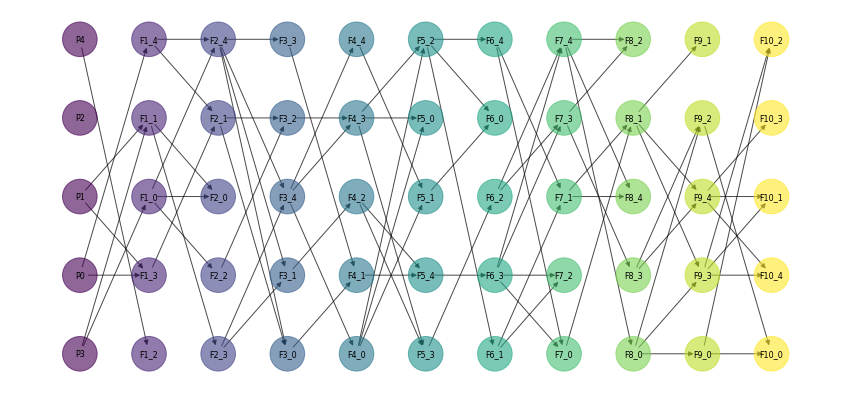

In [25]:
big_model = pg.PedigreeModel(
    pedigree=gen_list,
    chromosomes={"chr1": 100.0},
    seed=3,
)

big_model.draw_pedigree(figsize=(15,7))

In [26]:
big_result = big_model.simulate()
big_seq = big_result.local_forests("chr1", big_result.final_generation_homolog_ids())
big_df = pg.to_dataframe(big_result, big_seq)

print("number of local forests:", len(big_seq))
big_df.head()

number of local forests: 61


,chromosome,left,right,span,n_roots,n_nodes,n_edges,newicks
0,chr1,0.000,0.691,0.691,2,35,33,"[((((((((((F10_1_chr1_h0:1.0,F10_2_chr1_h1:1.0,F10_4_chr1_h0:1.0):1.0,(F10_3_chr1_h0:1.0,F10_3_chr1_h1:1.0):1.0):1.0):1.0):1.0):1.0):1.0):1.0):1.0):1.0);, ((((((((((F10_1_chr1_h1:1.0,F10_4_chr1_h1..."
1,chr1,0.691,2.458,1.767,2,36,34,"[((((((((((F10_1_chr1_h0:1.0,F10_4_chr1_h0:1.0):1.0,(F10_3_chr1_h0:1.0,F10_3_chr1_h1:1.0):1.0):1.0):1.0):1.0):1.0):1.0):1.0):1.0):1.0);, ((((((((((F10_1_chr1_h1:1.0,F10_4_chr1_h1:1.0):1.0):1.0):1...."
2,chr1,2.458,5.904,3.446,2,36,34,"[((((((((((F10_1_chr1_h0:1.0,F10_4_chr1_h0:1.0):1.0,(F10_3_chr1_h0:1.0,F10_3_chr1_h1:1.0):1.0):1.0):1.0):1.0):1.0):1.0):1.0):1.0):1.0);, ((((((((((F10_1_chr1_h1:1.0,F10_4_chr1_h1:1.0):1.0):1.0):1...."
3,chr1,5.904,6.524,0.620,2,36,34,"[((((((((((F10_1_chr1_h0:1.0):1.0,(F10_3_chr1_h0:1.0,F10_3_chr1_h1:1.0):1.0):1.0):1.0):1.0):1.0):1.0):1.0):1.0):1.0);, ((((((((((F10_1_chr1_h1:1.0,F10_4_chr1_h1:1.0):1.0):1.0):1.0,(((F10_0_chr1_h1..."
4,chr1,6.524,6.580,0.056,2,36,34,"[((((((((((F10_1_chr1_h0:1.0):1.0,(F10_3_chr1_h0:1.0,F10_3_chr1_h1:1.0):1.0):1.0):1.0):1.0):1.0):1.0):1.0):1.0):1.0);, ((((((((((F10_1_chr1_h1:1.0,F10_4_chr1_h1:1.0):1.0):1.0):1.0,(((F10_0_chr1_h1..."


In [27]:
big_ts = pg.to_tskit(big_result, big_seq)
print(big_ts)
print("sequence_length:", big_ts.sequence_length)
print("num_trees      :", big_ts.num_trees)
print("num_nodes      :", big_ts.num_nodes)
print("num_edges      :", big_ts.num_edges)

╔════════════════════════╗
║TreeSequence            ║
╠═══════════════╤════════╣
║Trees          │      61║
╟───────────────┼────────╢
║Sequence Length│   100.0║
╟───────────────┼────────╢
║Time Units     │ unknown║
╟───────────────┼────────╢
║Sample Nodes   │      10║
╟───────────────┼────────╢
║Total Size     │84.2 KiB║
╚═══════════════╧════════╝
╔═══════════╤════╤════════╤════════════╗
║Table      │Rows│Size    │Has Metadata║
╠═══════════╪════╪════════╪════════════╣
║Edges      │1974│61.7 KiB│          No║
╟───────────┼────┼────────┼────────────╢
║Individuals│  35│ 1.8 KiB│         Yes║
╟───────────┼────┼────────┼────────────╢
║Migrations │   0│ 8 Bytes│          No║
╟───────────┼────┼────────┼────────────╢
║Mutations  │   0│16 Bytes│          No║
╟───────────┼────┼────────┼────────────╢
║Nodes      │  60│ 5.2 KiB│         Yes║
╟───────────┼────┼────────┼────────────╢
║Populations│   0│ 8 Bytes│          No║
╟───────────┼────┼────────┼────────────╢
║Provenances│   0│16 Bytes│       

In [28]:
for i, tree in enumerate(big_ts.trees()):
    if i >= 3:
        break
    print("\ninterval:", tree.interval)
    print(tree.draw_text())


interval: Interval(left=0.0, right=0.6912948594362823)
        3             0      
        ┃             ┃      
        5             6      
        ┃             ┃      
        7             9      
        ┃             ┃      
       15            13      
        ┃             ┃      
       20            19      
        ┃             ┃      
       23            25      
        ┃             ┃      
       27            29      
    ┏━━━┻━━━┓         ┃      
   36      34        32      
    ┃       ┃         ┃      
   38      41        40      
 ┏━━┻━┓     ┃      ┏━━┻━━━┓  
45   43    49     46     48  
 ┃  ┏━┻┓  ┏━┻┓  ┏━━╋━━┓  ┏┻━┓
50 51 54 53 59 52 55 58 56 57


interval: Interval(left=0.6912948594362823, right=2.4581096073388684)
          3            0     
          ┃            ┃     
          5            6     
          ┃            ┃     
          7            9     
          ┃            ┃     
         15           13     
          ┃            ┃     
  

#### We could instead plot the same trees outside of tskit by using the newick from each local forest:

In [29]:
# plot the first tree from the tree sequence
toytree.tree(big_df.iloc[0].newicks[0]).draw();

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="324.096px" height="275.0px" viewBox="0 0 324.096 275.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="t3dc5bac93ebb4d75885121751617edac"> F10_1_chr1_h0 F10_2_chr1_h1 F10_4_chr1_h0 F10_3_chr1_h0 F10_3_chr1_h1

## 20. Summary

In this notebook we demonstrated that `pedigraph-sim` can:

- simulate chromosome inheritance through explicit pedigrees
- represent descendant homologs as mosaics of inherited segments
- reconstruct chromosome-local ancestry as a sequence of local forests
- export local forests to Newick and tabular forms
- optionally convert those forests into a `tskit` tree-sequence representation

At the moment, the main ancestry abstraction is a **`LocalForestSequence`**:
a sequence of interval-specific local trees/forests, rather than a single global ARG object.

The idea is that this makes the ancestry output especially easy to analyze and to export.